In [4]:
import numpy as np
# from network_sim.meiosis_models.super_simple import num_oocysts, num_oocysts_fast


    

ModuleNotFoundError: No module named 'numba'

In [3]:
from scipy.stats import nbinom


def precompute_nbinom_cdf(r, p, max_value=100):
    pmf = nbinom.pmf(np.arange(max_value + 1), r, p)
    cdf = np.cumsum(pmf)
    return cdf

oocyst_cdf = precompute_nbinom_cdf(3, 0.5, 100)
n_oocyst_choices = np.arange(101).astype(int)
# @njit
def num_oocysts_fast(): #hardcoded for speed
    random_sample = np.random.rand()
    for i, value in enumerate(oocyst_cdf):
        if random_sample < value:
            return max(1, n_oocyst_choices[i])
    return n_oocyst_choices[-1]

# @njit
def num_oocysts(model="fpg", min_oocysts=0):
    if model=="fpg":
        # Parameters
        r = 3  # number of failures. EMOD param Num_Oocyst_In_Bite_Fail
        p = 0.5  # probability of failure. EMOD param Probability_Oocyst_In_Bite_Fails

        return max(min_oocysts, np.random.negative_binomial(r, p))

    elif model == "fwd-dream":
        return min(np.random.geometric(0.5), 10)

    else:
        raise ValueError("Model not recognized.")


In [15]:
# Test outputs from the two functions:
a = np.empty(10000)
b = np.empty(10000)

for i in range(10000):
    a[i] = num_oocysts_fast()
    b[i] = num_oocysts(min_oocysts=1)

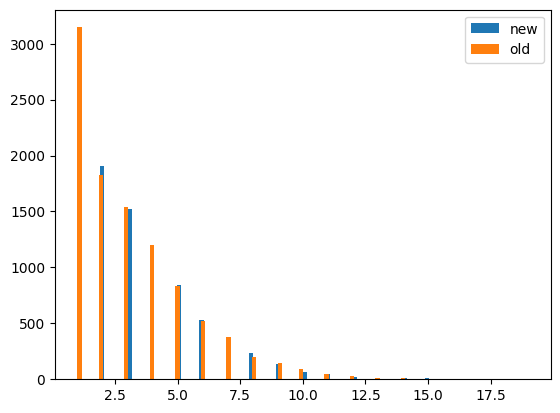

In [16]:
import matplotlib.pyplot as plt
plt.hist(a, bins=100, label="new")
plt.hist(b, bins=100, label="old")
plt.legend()
plt.show()

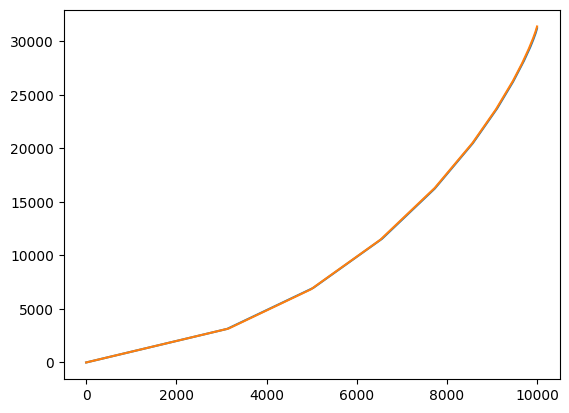

In [25]:
plt.plot(np.cumsum(np.sort(a)))
plt.plot(np.cumsum(np.sort(b)))

In [17]:
np.mean(a)

3.122

In [18]:
np.mean(b)

3.1388

In [19]:
np.median(a)

2.0

In [20]:
np.median(b)

3.0

In [21]:
np.percentile(a, 95)

8.0

In [22]:
np.percentile(b, 95)

8.0

# Test sporozoite number

In [26]:
# @njit
def num_sporozites(min_sporozoites=0):
    # Parameters
    r = 12  # number of failures. EMOD param Num_Sporozoite_In_Bite_Fail
    p = 0.5  # probability of failure. EMOD param Probability_Sporozoite_In_Bite_Fails
    return max(min_sporozoites,np.random.negative_binomial(r, p))

sporozoite_cdf = precompute_nbinom_cdf(12, 0.5, 100)
n_sporozoite_choices = np.arange(101).astype(int)
# @njit
def num_sporozites_fast(): #hardcoded for speed
    random_sample = np.random.rand()
    for i, value in enumerate(sporozoite_cdf):
        if random_sample < value:
            return max(1, n_sporozoite_choices[i])
    return 1

In [27]:
# Test outputs from the two functions:
a = np.empty(10000)
b = np.empty(10000)

for i in range(10000):
    a[i] = num_sporozites_fast()
    b[i] = num_sporozites(min_sporozoites=1)

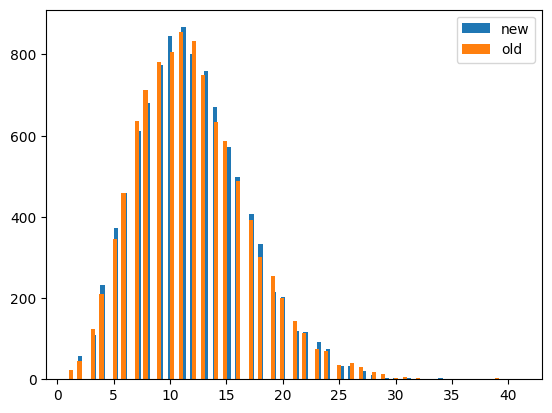

In [28]:
import matplotlib.pyplot as plt
plt.hist(a, bins=100, label="new")
plt.hist(b, bins=100, label="old")
plt.legend()
plt.show()

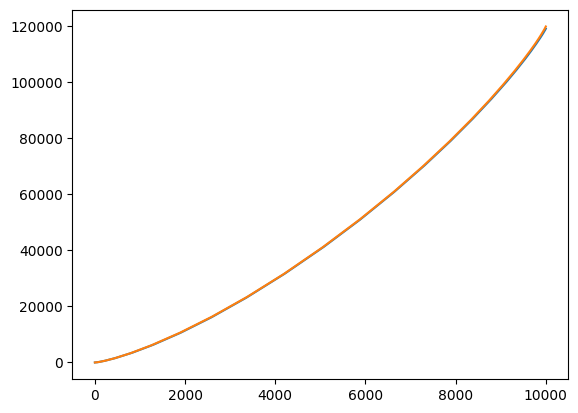

In [29]:
plt.plot(np.cumsum(np.sort(a)))
plt.plot(np.cumsum(np.sort(b)))


In [30]:
np.mean(a)

11.9111

In [31]:
np.mean(b)

11.9894

In [32]:
np.min(a)

1.0

In [33]:
np.min(b)

1.0

# Infectiousness distribution

In [34]:
import pandas as pd

df = pd.read_csv("infection_lookup.csv")
df.head()

,infection_id,human_id,infectiousness,days_until_clearance,gametocyte_density
0,89730,0,0.007301,1.0,3.643587
1,89731,0,0.007301,1.0,3.643587
2,89732,0,0.007301,1.0,3.643587
3,89733,0,0.007301,1.0,3.643587
4,89734,0,0.007301,1.0,3.643587


In [39]:
foo = df.groupby("human_id").size().reset_index()

In [40]:
foo

,human_id,0
0,0,22
1,2,12
2,3,4
3,4,6
4,6,10
...,...,...
848,995,16
849,996,4
850,997,1
851,998,5


(array([172., 248., 180., 103.,  72.,  42.,  26.,   3.,   3.,   4.]),
 array([ 1. ,  6.6, 12.2, 17.8, 23.4, 29. , 34.6, 40.2, 45.8, 51.4, 57. ]),
 <BarContainer object of 10 artists>)

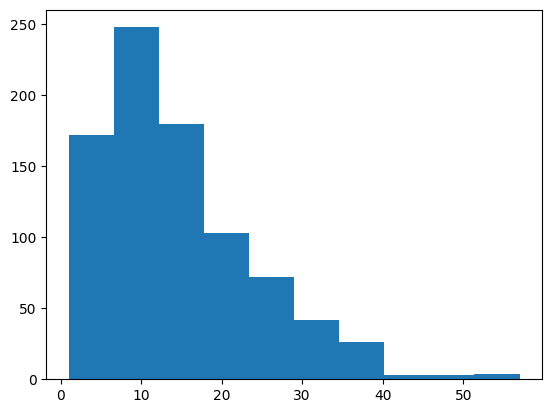

In [41]:
plt.hist(foo[0])